In [1]:
# import system libraries
import logging
import sys, copy
# import scientific libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.signal
from scipy.interpolate import InterpolatedUnivariateSpline as spline
import h5py
import pandas as pd
# import data analysis libraries
from ldc.waveform.lisabeta import FastBHB
import lisabeta.lisa.lisa as lisa
from lisabeta.lisa.lisa import EvaluateTDIFreqseries
import lisabeta.tools.pyspline as pyspline
import lisabeta.lisa.lisatools as lisatools
import lisabeta.tools.pytools as pytools
from ldc.common import tools
from ldc.lisa.noise import AnalyticNoise, get_noise_model
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import lisaconstants
# import sampler libraries
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import uniform_dist, ProbDistContainer
from ldc.waveform.waveform import HpHc

mpl.rcParams.update(mpl.rcParamsDefault)

Could not import fastgb. Please pip install fastgb


# Set up injection and find noiseless Afull and Efull. Set up Npsd, timing, and frequencies

In [2]:
#imports all dependencies and homebrewed functions
import LISA_TTL_Functions as foc

In [3]:
#set up the injection

pMBHB_ldc = {'EclipticLatitude': -0.30300442294174235,
 'EclipticLongitude': 1.2925183861048521,
 'PolarAngleOfSpin1': 1.2031361791056812,
 'PolarAngleOfSpin2': 2.097303543065685,
 'Spin1': 0.747377,
 'Spin2': 0.8388,
 'Mass1': 1323277.47932, #original 1323277.47932
 'Mass2': 612485.5060299999, #original 612485.5060299999
 'CoalescenceTime': 11526944.921879262,
 'PhaseAtCoalescence': 1.2201968860015653,
 'InitialPolarAngleL': 2.6919824500032945,
 'InitialAzimuthalAngleL': 1.808398497592109,
 'Redshift': 1.73941,
 'Distance': 13470.983559 , #13470.983559 original
 'ObservationDuration': 31558149.763545603,
 'Cadence': 3.0}

snr = 22295 for distance 1347.983559 \
snr = 223 for distance 134700 \
snr = 12021 for distance 2500 \
snr = 2230 for distance 13470 \
snr = 7026 for mass x10 distance 2500 \
snr = 1303 for mass x10 distance 13470 \
snr = 130 for mass x10 distance 134700 \
snr = 2096 for mass x.1 distance 2500 \
snr = 389 for mass x0.1 distance 13470 \
snr = 38 for mass x0.1 distance 134700

In [4]:
snr_unrounded = foc.snr_check(pMBHB_ldc)
snr = int(snr_unrounded)
save_name = 'heterodyne_gr_5000'
print(snr)

2230.9845934810273
2230


In [5]:
#establish t_min, max, separation and number of samples
t_min = 0
t_max = pMBHB_ldc["CoalescenceTime"]+1000
dt = 0.25
df = 1/t_max

t = np.arange(t_min, t_max, dt)

In [6]:
#set up the injection in lisabeta terms
FBH = FastBHB("MBHB", T=t_max, delta_t=dt, approx="IMRPhenomD")

pMBHB = FBH.rename_as_lisabeta(pMBHB_ldc)

print(pMBHB.keys())

dict_keys(['beta', 'lambda', 'chi1', 'chi2', 'm1', 'm2', 'Deltat', 'phi', 'dist', 'psi', 'inc'])


In [7]:
#background settings
waveform_params_smbh = {
    "minf": 1e-5,
    "maxf": 1,
    "t0": 0.0,
    "timetomerger_max": 1.0,
    "tmax": 1.0,
    "TDI": "TDI2AET",
    "LISAconst": "Proposal",
    "responseapprox": "full",
    "frozenLISA": False,
    "TDIrescaled": False,
    "modes": None,
    # Waveform approximant and set of harmonics to use 
    "approximant": "IMRPhenomHM"
}

In [8]:
#generate interpolated signal
tdisignal = lisa.GenerateLISATDISignal_SMBH(pMBHB, **waveform_params_smbh)
tdi = tdisignal['tdi']
mbh_lb_2 = tdi[(2,2)]

In [9]:
#Fvec for interpolation
fmin = mbh_lb_2['freq'][0]
fmax = mbh_lb_2['freq'][-1]
ndata = int(t_max/dt)
df = 1/t_max

# Get the full frequencies
if (ndata % 2)==0:              # Get the number of requencies
    nfft = int((ndata/2)+1)
else:
    nfft = int((ndata+1)/2)

F = df*nfft                 # make the positive frequency vector
fvec = np.arange(0, F, df)

# Get the frequencies of interest
f_inds = np.where(np.logical_and(fvec >= fmin, fvec < fmax))
fvec = fvec[f_inds]
fvec = fvec[fvec>0]
print(fvec.max())

0.020976245257821734


In [10]:
#downsample fvec

if len(fvec != 3016):
    fvec_coarse = fvec[::80]  # 3016 bins
    print(len(fvec_coarse))
    fvec = np.ascontiguousarray(fvec_coarse)
else:
    pass


3016


[(2, 2), (2, 1), (3, 3), (3, 2), (4, 4), (4, 3)]


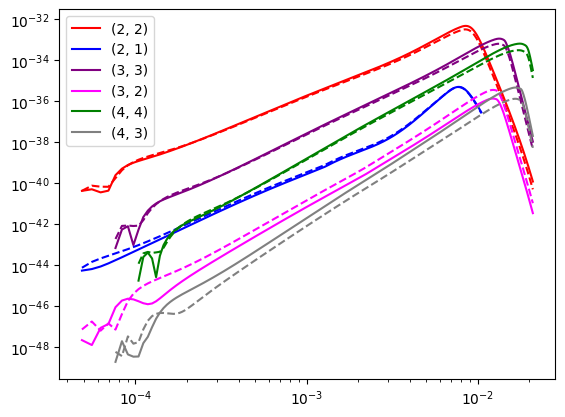

In [ ]:
#generate data
modesf  = tdisignal['tdi']['modes']
colors = ['red', 'blue', 'purple', 'magenta', 'green', 'gray']
print(modesf)
A_full = np.zeros(len(fvec), dtype=complex)
E_full = np.zeros(len(fvec), dtype=complex)

for i in range(len(modesf)):
    mbh_lb = tdi[modesf[i]]

    mask = (fvec >= mbh_lb['freq'].min()) & (fvec <= mbh_lb['freq'].max())
    
    #phase
    splPh = spline(mbh_lb['freq'], mbh_lb['phase'], ext='raise')
    #A
    splAr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan1'])
    splAi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan1'])
    #E
    splEr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan2'])
    splEi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan2'])

    #plot partials
    A_partial = np.conjugate((splAr(fvec[mask]) + 1.j*splAi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))
    E_partial = np.conjugate((splEr(fvec[mask]) + 1.j*splEi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))
    plt.loglog(fvec[mask], np.abs(A_partial)**2, label = str(modesf[i]), color = colors[i])
    plt.loglog(fvec[mask], np.abs(E_partial)**2, '--', color = colors[i])
    plt.legend()

    A_full[mask] += A_partial
    E_full[mask] += E_partial

Nmodel = AnalyticNoise(fvec, model="SciRDv1") # or whatever version you prefer. In the previous notebook we used "sangria"
Npsd = Nmodel.psd(option='A', tdi2=True)

# constructing signal at each Fouriner freq.

In [12]:
Afull = A_full
Efull = E_full

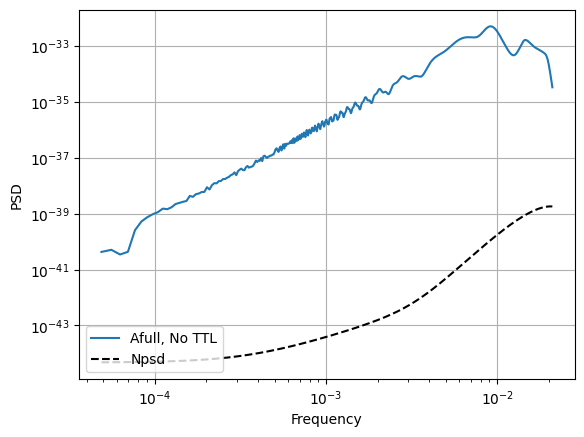

In [13]:
fig, ax = plt.subplots()
ax.loglog(fvec, np.abs(Afull)**2, label = 'Afull, No TTL')
ax.loglog(fvec, Npsd, '--', color = 'k', label = 'Npsd')
ax.set_xlabel('Frequency')
ax.set_ylabel('PSD')
ax.legend(loc = 'lower left')
ax.grid()

# Set up the MCMC: array for trials, likelihood, priors, initial condition, temps, walkers, samples, etc

In [14]:
#now we set things up for mcmc
#solving for chirpmass and ratio
m1 = pMBHB['m1']
m2 = pMBHB['m2']
q = m1/m2
Mc = (m1+m2)*(q/(1+q)**2)**0.6

src0 = pMBHB.copy()
src0.pop("m1"); src0.pop("m2")
src0["Mchirp"] = Mc
src0["q"] = q
src0['psi'] += np.pi
src0['phi'] -= np.pi

keys = src0.keys()

#create the array to be altered in likelihood
src = copy.deepcopy(src0)

In [15]:
#interpolated likelihood info
m1 = pMBHB['m1']
m2 = pMBHB['m2']

q = m1/m2
Mc = (m1+m2)*(q/(1+q)**2)**0.6

pMBHB["Mchirp"] = Mc
pMBHB["q"] = q

pMBHB_fit = copy.deepcopy(pMBHB)

# Remove those keys, otherwise the code will
# fit for m1 and m2 instead of Mchirp and q.
del pMBHB_fit["m1"]
del pMBHB_fit["m2"]

DA = Afull.copy()
DE = Efull.copy()

In [16]:
#Interpolated likelihood
def likelihood_interp(pvector):
    src = {k: v for k, v in zip(keys, pvector)}

    tdisignal = lisa.GenerateLISATDISignal_SMBH(src, gridfreq=fvec, **waveform_params_smbh)
    modes = tdisignal['tdi']['modes']

    hA = np.zeros(len(fvec), dtype=complex)
    hE = np.zeros(len(fvec), dtype=complex)

    for i in range(len(modes)):
        mbh_lb = tdisignal['tdi'][modes[i]]

        mask = (fvec >= mbh_lb['freq'].min()) & (fvec <= mbh_lb['freq'].max())
        fvec_m = fvec[mask]

        splPh = spline(mbh_lb['freq'], mbh_lb['phase'])
        splAr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan1'])
        splAi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan1'])
        
        splEr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan2'])
        splEi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan2'])

        phase_factor = np.exp(1j * splPh(fvec_m))

        hA[mask] += np.conjugate((splAr(fvec_m) + 1.j*splAi(fvec_m)) * phase_factor)
        hE[mask] += np.conjugate((splEr(fvec_m) + 1.j*splEi(fvec_m)) * phase_factor)

    SN_m = 4.0 * df * np.sum(np.real(DA * np.conjugate(hA)) / Npsd) + 4.0 * df * np.sum(np.real(DE * np.conjugate(hE)) / Npsd)

    XX = 4.0 * df * np.sum(np.abs(hA)**2 / Npsd) + 4.0 * df * np.sum(np.abs(hE)**2 / Npsd)

    loglik = SN_m - 0.5 * XX

    return loglik
    

In [ ]:
day_sec = 86400

priors = {"mbh": ProbDistContainer({
    0: uniform_dist(-np.pi/2, np.pi/2), #lambda
    1: uniform_dist(-np.pi, np.pi), #beta
    2: uniform_dist(-1, 1), #chi1
    3: uniform_dist(-1, 1), #chi2
    4: uniform_dist(100*day_sec, 175*day_sec), #deltat
    5: uniform_dist(-np.pi, np.pi), #phi
    6: uniform_dist(500.0, 2000000.0), #dist 
    7: uniform_dist(0., np.pi), #psi
    8: uniform_dist(0., np.pi), #inc
    9: uniform_dist(1e4, 1e7), #mchirp 
    10: uniform_dist(1, 10), #q
})}

ndims = {"mbh": 11}

In [ ]:
ntemps = 5
nwalkers = 22
nsamples = 5000
ndims = {"mbh": 11}

In [ ]:
theta0 = np.array([[np.hstack(
          (np.random.randn(ndims["mbh"]) * 1e-8) + np.array(list(src0.values())))
          for i in range(nwalkers)]
          for _ in range(ntemps)])

start_state = State({"mbh": theta0})

In [ ]:

sampler = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood_interp,
    priors,
    args=(),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps=ntemps),
    nleaves_max=dict(mbh=1),
)


# Run the MCMC

In [ ]:
sampler.run_mcmc(start_state, nsamples, progress=True, store = True)

# Plot corner and walkers

In [ ]:
#define truths
keys = src0.keys()
labels = list(keys)

inj=np.array(list(src0.values()))

truths = inj.flatten()
labels_final = labels

In [ ]:
truth = pd.DataFrame(data = truths , columns = ['truths'])
csv_filename_truth = save_name + "_snr_truth.csv"
truth.to_csv(csv_filename_truth, index=False)

In [ ]:
burn = 0

In [ ]:
c = ChainConsumer()

samples_2ch = sampler.get_chain()["mbh"][:, 0].reshape(-1, 11)

dfs_2chnls = pd.DataFrame(samples_2ch[burn:, :], columns = keys)

c.add_chain(Chain(samples=dfs_2chnls, name="noiseless", color="blue"))
c.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

c.plotter.plot()
c.plotter.plot_walks()

In [ ]:
csv_filename_0mm = "0mm_"+ save_name + "_snr_chains.csv"
dfs_2chnls.to_csv(csv_filename_0mm, index=False)
print(f"Chain data saved to {csv_filename_0mm}")

In [ ]:
print(

# Add 1mm noise to the waveform

In [ ]:
#a constant
fstar = 0.0190854 #c/L/(2*np.pi)

In [ ]:
#generate noise psd for 1mm
psd_sqrt = (6e-11*(np.sin(2*freq/fstar)**2) + 1e-12)/2.5e9 #2.5e9 is armlength
#1mm eyeball -> 6e-11
#2mm eyeball -> 2e-10
#10mm eyeball -> 8e-10
psd = ((6e-11*(np.sin(2*freq/fstar)**2) + 1e-12)/2.5e9)**2/(df*4)

#Add noise function
def randc(r):
    return r/np.sqrt(2)*(np.random.randn(*r.shape) + 1j*np.random.randn(*r.shape))

#create noise fft
noise_fft = randc(psd_sqrt)

In [ ]:
#add noisy noise to signal
Afull = A_full+ noise_fft/np.sqrt(df*4)
Efull = E_full+ noise_fft/np.sqrt(df*4)

In [ ]:
fig1, ax1 = plt.subplots()
ax1.loglog(freq, np.abs(A_full)**2, label = 'Afull, No TTL')
ax1.loglog(freq, np.abs(Afull)**2, label = 'Afull, TTL')
ax1.loglog(freq, Npsd, '--', color = 'k', label = 'Npsd')
ax1.loglog(freq, psd, color = 'silver' ,label = 'TTL psd')
ax1.set_xlabel('Frequency')
ax1.set_ylabel('PSD')
ax1.legend(loc = 'lower center')
ax1.grid()

# Rerun the same MCMC with 1mm

In [ ]:
sampler2 = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood,
    priors,
    args=(),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps=ntemps),
    nleaves_max=dict(mbh=1),
)

In [ ]:
sampler2.run_mcmc(start_state, nsamples, progress=True)

# Plot walkers and corners 1mm

In [ ]:
a = ChainConsumer()

one_samples = sampler2.get_chain()["mbh"][:, 0].reshape(-1, 11)

#burn = 30000
one_samp= pd.DataFrame(one_samples[burn:, :], columns = keys)

a.add_chain(Chain(samples=one_samp, name="1mm", color="yellow"))
a.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

a.plotter.plot()
a.plotter.plot_walks()

In [ ]:
csv_filename_1mm = "1mm_"+ str(snr) + difference + "_snr_chains.csv"
one_samp.to_csv(csv_filename_1mm, index=False)
print(f"Chain data saved to {csv_filename_1mm}")

# Add 2mm noise to the waveform

In [ ]:
#generate noise psd for 1mm
psd_sqrt = (2e-10**(np.sin(2*freq/fstar)**2) + 1e-12)/2.5e9 #2.5e9 is armlength
#1mm eyeball -> 6e-11
#2mm eyeball -> 2e-10
#10mm eyeball -> 8e-10


noise_fft = randc(psd_sqrt)

#add noisy noise to signal
Afull = A_full+ noise_fft/np.sqrt(df*4)
Efull = E_full+ noise_fft/np.sqrt(df*4)

# Rerun the same MCMC with 2mm

In [ ]:
sampler3 = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood,
    priors,
    args=(),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps=ntemps),
    nleaves_max=dict(mbh=1),
)

In [ ]:
sampler3.run_mcmc(start_state, nsamples, progress=True)

# Corners and Chains for 2.3 mm

In [ ]:
b = ChainConsumer()

two_samples = sampler3.get_chain()["mbh"][:, 0].reshape(-1, 11)

#burn = 800000
two_samp= pd.DataFrame(two_samples[burn:, :], columns = keys)

b.add_chain(Chain(samples=two_samp, name="2mm", color="red"))
b.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

b.plotter.plot()
b.plotter.plot_walks()

In [ ]:
csv_filename_2mm = "2mm_"+ str(snr) + difference + "_snr_chains.csv"
two_samp.to_csv(csv_filename_2mm, index=False)
print(f"Chain data saved to {csv_filename_2mm}")

# Let'd do a small checkin with those three chains

In [ ]:
check = ChainConsumer()

check.add_chain(Chain(samples=dfs_2chnls, name="noiseless", color="blue"))
check.add_chain(Chain(samples=one_samp, name="1 mm/rad", color="purple"))
check.add_chain(Chain(samples=two_samp, name="2.3 mm/rad", color="red"))
check.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

check.plotter.plot()
#check.plotter.plot_walks()